<a href="https://colab.research.google.com/github/NABI-SNU/book/blob/main/tutorials/Session_2_BayesianInference/student/Tutorial1.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>   <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NABI-SNU/book/main/tutorials/Session_2_BayesianInference/student/Tutorial1.ipynb" target="_blank"><img alt="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"/></a>


# Tutorial 1: Marginalization — Gaussian and mixture of Gaussians

**Session 2: Bayesian Inference** · **NABI-SNU**

This worksheet is **exercises only**. The **instructor** notebook contains full solutions.


## Learning goals

1. Marginalize a **bivariate Gaussian** and connect the algebra to a 1-D marginal density.
2. Interpret a **mixture of Gaussians (MoG)** as a marginal over a discrete latent variable.
3. Use **SymPy** for integrals/simplification and **Matplotlib** for joint vs marginal plots.

## Setup

Run the import cell below (add any extra imports you need).


In [1]:
%pip install sympy

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from sympy import (
    symbols,
    integrate,
    simplify,
    sqrt,
    pi,
    exp,
    tanh, 
    oo,
    init_printing,
)

from sympy.printing.latex import LatexPrinter
from IPython.display import display, Markdown

class ExpLatexPrinter(LatexPrinter):
    def _print_exp(self, expr):
        arg = self._print(expr.args[0])
        return r"\exp{\left(" + arg + r"\right)}"


def latex_with_exp(expr, **kwargs):
    printer = ExpLatexPrinter(settings=kwargs)
    return printer.doprint(expr)

init_printing()
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})


---

## Exercise 1 — Bivariate Gaussian: marginal in SymPy

This expression is the standard **zero-mean correlated Gaussian** in 2D. If
$$
\Sigma = \begin{bmatrix}
\sigma_x^2 & \rho\,\sigma_x\sigma_y \\
\rho\,\sigma_x\sigma_y & \sigma_y^2
\end{bmatrix},
$$
then the Gaussian density is proportional to
$\exp\!\big(-\tfrac12 [x\;y] \Sigma^{-1} [x\;y]^\top\big)$. Expanding that quadratic form gives exactly the term below:
$$
f_{X,Y}(x,y) \propto \exp\left(-\frac{1}{2(1-\rho^2)}\left(\frac{x^2}{\sigma_x^2} - \frac{2\rho xy}{\sigma_x \sigma_y} + \frac{y^2}{\sigma_y^2}\right)\right).
$$

**Tasks.**

1. Define symbolic $\sigma_x, \sigma_y > 0$ and correlation $\rho \in (-1,1)$ in SymPy.
2. Write the **normalized** joint density $f_{X,Y}(x,y)$ (prefactor $\frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}}$).
3. Integrate over $y$ from $-\infty$ to $\infty$ to obtain the marginal $f_X(x)$ and simplify.
4. Confirm that $f_X(x)$ is Gaussian and identify the marginal variance as $\sigma_x^2$. That is, it is equal to 
$$
f_X(x)=\frac{1}{\sqrt{2\pi}\,\sigma_x}\exp\!\left(-\frac{x^2}{2\sigma_x^2}\right),
$$


In [14]:
x, y = symbols("x y", real=True)
sx, sy = symbols("sigma_x sigma_y", positive=True)
eta = symbols("eta", real=True)
rho = tanh(eta)  # Enforces rho in (-1, 1)

norm = 1 / (2 * pi * sx * sy * sqrt(1 - rho**2))
exponent = -1 / (2 * (1 - rho**2)) * (
    x**2 / sx**2 - 2 * rho * x * y / (sx * sy) + y**2 / sy**2
)
f_xy = norm * exp(exponent)

raise NotImplementedError("Replace with your SymPy derivation.")
f_x = integrate(...)
f_x_simple = simplify(f_x)
display(Markdown(f" The marginal is $$f_X(x) = {latex_with_exp(f_x_simple)}$$."))

NotImplementedError: Replace with your SymPy derivation.

---

## Exercise 2 — Joint vs marginal plots (Matplotlib)

Using **numerical** evaluation (e.g. `scipy.stats.multivariate_normal` or a grid):

1. Choose $\sigma_x=1$, $\sigma_y=1.5$, $\rho=0.6$.
2. Plot a **contour or heatmap** of $f_{X,Y}$ over a sensible $(x,y)$ window.



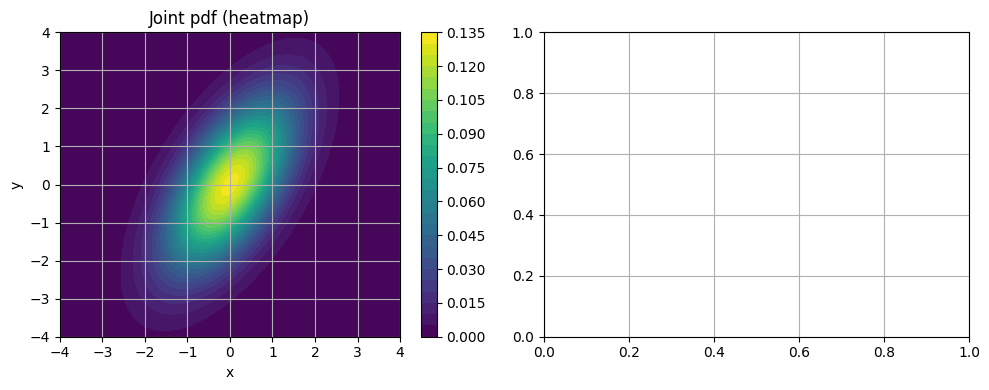

In [ ]:
sx_, sy_, rho_ = 1.0, 1.5, 0.6
mean = np.array([0.0, 0.0])
cov = np.array([[sx_**2, rho_ * sx_ * sy_], [rho_ * sx_ * sy_, sy_**2]])
rv = multivariate_normal(mean, cov)

xg = np.linspace(-4, 4, 200) # [-4, -3.96, -3.92, ..., 3.92, 3.96, 4]
yg = np.linspace(-4, 4, 200) # [-4, -3.96, -3.92, ..., 3.92, 3.96, 4]
Xg, Yg = np.meshgrid(xg, yg) # Xg.shape = (200, 200), Yg.shape = (200, 200)
pos = np.dstack((Xg, Yg)) # pos.shape = (200, 200, 2)
Z = rv.pdf(pos) # Z.shape = (200, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cs = axes[0].contourf(Xg, Yg, Z, levels=30)
fig.colorbar(cs, ax=axes[0])
axes[0].set_title("Joint pdf (heatmap)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()

3. Plot the **marginal** $f_X(x)$ on the same figure using the formula from Exercise 1.

In [ ]:
raise NotImplementedError("Replace with your plotting code.")
marg = ...
axes[1].plot(xg, marg, label=r"$f_X(x)$ analytic")
display(fig)

NotImplementedError: Replace with your plotting code.

4. Plot the **marginal** histogram of $X$ on the same figure.

In [23]:
raise NotImplementedError("Replace with your plotting code.")

samples = ...
axes[1].hist(..., bins=60, density=True, alpha=0.35, label="X marginal hist")
axes[1].set_title("Marginal over x")
axes[1].set_xlabel("x")
axes[1].legend()

display(fig)


NotImplementedError: Replace with your plotting code.

---

## Exercise 3 — Mixture of Gaussians as marginalization

Let $Z \in \{1,\dots,K\}$ with $\mathbb{P}(Z=k)=\pi_k$ and $(X\mid Z=k) \sim \mathcal{N}(\mu_k, \sigma_k^2)$.
It can be shown that $p_X(x)$ is given by the following expression:
$$
p_X(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x; \mu_k, \sigma_k^2).
$$
1. For $K=2$, implement $p_X(x)$ numerically and **plot** it for nontrivial parameters (given below). 
2. For the same non-trivial parameters, find $\mathbb{E}[X]$ and $\mathrm{Var}(X)$ both analytically and via Monte Carlo.


In [32]:
def mog_pdf(x: float, 
    weights: list[float], 
    mus: list[float], 
    sigmas: list[float]) -> float:
    p = 0
    raise NotImplementedError("Replace with mixture definition and plot.")
    return p

x = np.linspace(-8, 10, 500)
weights = [0.4, 0.6]
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

plt.figure()
values = []
for i in range(len(x)):
    values.append(mog_pdf(x[i], weights, mus, sigmas))
values = np.array(values)
plt.plot(x, values) 
plt.title("Two-component Gaussian mixture")
plt.xlabel("x")
plt.ylabel("density")
plt.show()


NotImplementedError: Replace with mixture definition and plot.

<Figure size 700x450 with 0 Axes>

In [37]:
# Empirical marginalization

pi = 0.4
n = 200_000
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

rng = np.random.default_rng(0)
raise NotImplementedError("Replace with your Monte Carlo code.")
x_s = ...
mu_hat, var_hat = x_s.mean(), x_s.var(ddof=0)

print("MC mean:", mu_hat, "\n MC var:", var_hat)

NotImplementedError: Replace with your Monte Carlo code.

In [36]:
# Analytical marginalization

pi = 0.4
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

raise NotImplementedError("Replace with your analytical code.")
mu_th = ...
ex2 = ...
var_th = ...
print("Theoretical mean", mu_th, "\nTheoretical var", var_th)


NotImplementedError: Replace with your analytical code.